# 07 — Baseline separation, time-series comparison and instrument bias

Everything so far has treated a sensor's reading as a single quantity to be cleaned, corrected and compared. But a PM2.5 measurement is really a sum of contributions on different scales: air blown into Leeds from elsewhere, the general urban haze, and whatever is happening within a few hundred metres of the sensor. Comparing raw time series between two sites mostly compares the part they share, which is why almost every sensor in the network rises and falls together and why the CSI heatmap is dominated by high values.

This notebook separates the two, writing each sensor's series as

$$C_i(t) = B(t) + I_i(t)$$

a baseline $B(t)$ common to the network and a local increment $I_i(t)$ specific to sensor $i$. The split follows the standard decomposition of urban particulate matter into regional, urban and local contributions (Lenschow et al., 2001). Once the shared signal is removed, three questions that could not be asked before become answerable:

1. **Which areas have local sources?** The mean increment is a direct measure of how much a site adds to the air it sits in.
2. **What are those sources?** The increment's shape through the day, contrasted between weekdays and weekends, separates traffic from sources that ignore the working week.
3. **Which sensors are biased?** On quiet, well-mixed nights every working sensor should see the same air, so a persistent departure from the network is a property of the instrument. Regressing a sensor against the network then splits that bias into an additive offset and a calibration-gain error — two different faults with two different physical causes.

The third point is what makes this more than a descriptive exercise: it turns "SL051 disagrees with everyone" into a bias in µg/m³ that a site visit can act on, and it does so through a route that shares no logic with the CSI, so the two methods provide independent evidence.

Methods live in `src/baseline.py`; the functions were tested against synthetic series with known injected faults before being run on the network.

In [ ]:
import re, sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src.config import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.baseline import (network_baseline, rolling_baseline, local_increment,
                          night_mask, well_mixed_mask, instrument_offset,
                          offset_gain, diurnal_profile, classify_sites)

def short_code(name: str) -> str:
    m = re.search(r"SL_?(\d+)", str(name))
    return f"SL{int(m.group(1)):03d}" if m else str(name)

# The per-sensor hourly table built in notebook 06 (clean rows, Barkjohn-corrected,
# hours with >= MIN_READ_PER_HOUR readings). 
hm = pd.read_parquet(PROCESSED / "network_hourly_sensors.parquet")
hm.index = pd.to_datetime(hm.index, utc=True)
hm.columns = [short_code(c) for c in hm.columns]
hm = hm.sort_index()

print(f"hourly matrix: {hm.shape[0]:,} hours x {hm.shape[1]} sensors")
print(f"period: {hm.index.min().date()} -> {hm.index.max().date()}")
print(f"hours with >= {MIN_SENSORS_PER_HOUR} sensors reporting: "
      f"{(hm.notna().sum(axis=1) >= MIN_SENSORS_PER_HOUR).sum():,}")

hourly matrix: 37,697 hours x 47 sensors
period: 2022-03-07 -> 2026-07-04
hours with >= 5 sensors reporting: 33,477


## 1  The regional baseline

Two baselines are computed and compared.

The **spatial** baseline takes a low quantile *across sensors* at each hour. The reasoning is that at any given moment the cleanest sites in the network are the ones with no local source active, so their concentration approximates what everyone is breathing before local additions. The 10th percentile is used rather than the minimum: the minimum would be decided by a single sensor, and a sensor reading systematically low would win it every hour, which is exactly the failure this notebook is trying to detect.

The **temporal** baseline takes a low quantile of a centred seven-day window at a single site, exploiting the fact that local sources are intermittent while the background is persistent. It needs no network, but it cannot distinguish a background from a local source that never switches off.

A note on the alternative of using a quiet night as the baseline. It is intuitive — traffic between 01:00 and 05:00 is minimal — but night air is not automatically clean air: the nocturnal boundary layer is shallow, so whatever is emitted accumulates in a thinner volume, and in winter domestic burning peaks in the evening and decays overnight. Night is therefore used later as a *condition* for isolating instrument behaviour rather than as the definition of background.

In [2]:
base_spatial = network_baseline(hm, q=BASELINE_Q, min_sensors=MIN_SENSORS_PER_HOUR)
net_median   = hm.median(axis=1).where(hm.notna().sum(axis=1) >= MIN_SENSORS_PER_HOUR)

print(f"spatial baseline valid for {base_spatial.notna().sum():,} hours "
      f"({base_spatial.notna().mean():.0%} of the record)")
print(f"median baseline {base_spatial.median():.2f} ug/m3   "
      f"vs network median {net_median.median():.2f} ug/m3")

# temporal baseline for one well-covered sensor, to compare the two approaches
ref = hm.notna().sum().idxmax()
base_temporal = rolling_baseline(hm[ref], window=BASELINE_WINDOW, q=0.05)
print(f"\ntemporal baseline computed for {ref} "
      f"(most complete sensor, {hm[ref].notna().sum():,} valid hours)")

spatial baseline valid for 33,477 hours (89% of the record)
median baseline 1.31 ug/m3   vs network median 2.41 ug/m3

temporal baseline computed for SL024 (most complete sensor, 26,637 valid hours)


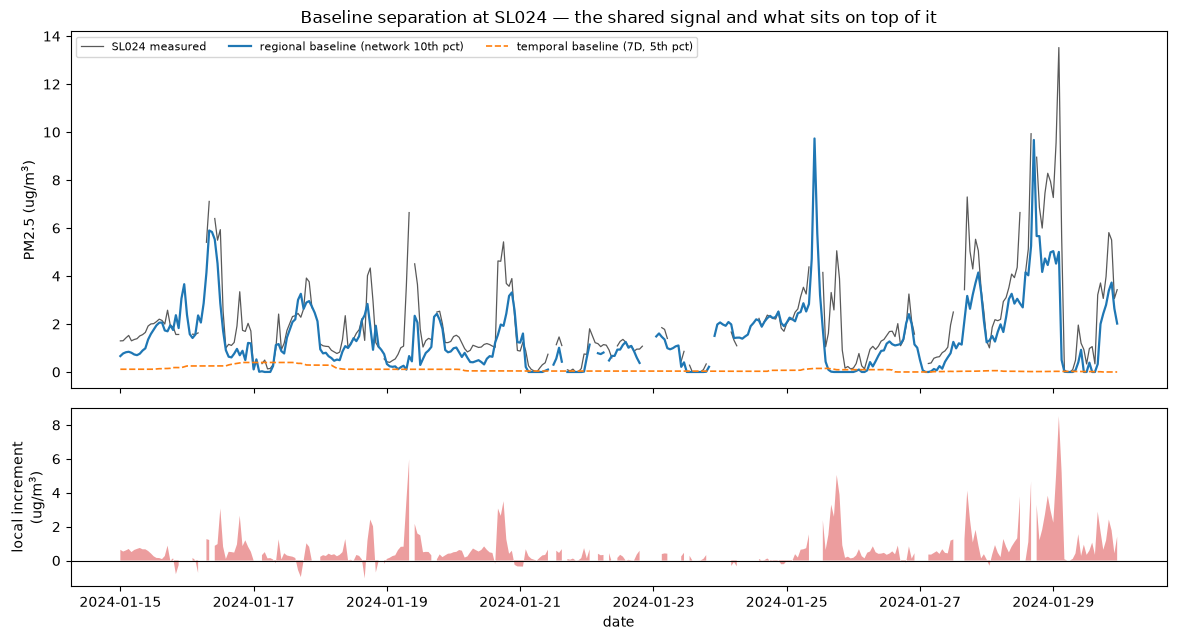

In [3]:
# A fortnight in winter, when local sources are most active, showing the split.
win = slice("2024-01-15", "2024-01-29")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(hm.loc[win, ref].index, hm.loc[win, ref], lw=0.9,
         color="0.35", label=f"{ref} measured")
ax1.plot(base_spatial.loc[win].index, base_spatial.loc[win], lw=1.6,
         color="tab:blue", label=f"regional baseline (network {int(BASELINE_Q*100)}th pct)")
ax1.plot(base_temporal.loc[win].index, base_temporal.loc[win], lw=1.2,
         color="tab:orange", ls="--", label=f"temporal baseline ({BASELINE_WINDOW}, 5th pct)")
ax1.set_ylabel("PM2.5 (ug/m$^3$)")
ax1.legend(fontsize=8, ncol=3)
ax1.set_title(f"Baseline separation at {ref} — the shared signal and what sits on top of it")

incr_ref = hm.loc[win, ref] - base_spatial.loc[win]
ax2.fill_between(incr_ref.index, 0, incr_ref, color="tab:red", alpha=0.45, lw=0)
ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("local increment\n(ug/m$^3$)")
ax2.set_xlabel("date")

fig.tight_layout()
fig.savefig(OUT_FIGURES / "baseline_decomposition.png", dpi=200, bbox_inches="tight")
plt.show()

## 2  Comparing areas: how much does each site add?

With the shared signal removed, sites can be compared on what they contribute locally. Sensors are grouped by distance from City Square, which is a crude geometric proxy for site character rather than a land-use survey — a sensor 10 km out on a trunk road is not really suburban — so the grouping is reported with its boundaries and should be read as indicative.

The quantity of interest is the median local increment: the typical amount by which a site exceeds the regional baseline. A site with no local sources should sit near zero. A persistently negative increment is a warning sign of a different kind, since a sensor cannot really measure cleaner air than the regional background for long.

In [4]:
incr = local_increment(hm, base_spatial)

sensors = pd.read_csv(OUT_TABLES / "study_sensors.csv")
sensors["code"] = sensors["sensor_name"].map(short_code)
coords = sensors.set_index("code")[["lat", "lon"]]
sites  = classify_sites(coords.loc[coords.index.intersection(hm.columns)])

site_stats = pd.DataFrame({
    "median_increment": incr.median(),
    "p90_increment":    incr.quantile(0.90),
    "median_measured":  hm.median(),
    "valid_hours":      hm.notna().sum(),
}).join(sites[["km_from_centre", "site_type"]], how="inner")
site_stats = site_stats[site_stats["valid_hours"] >= 500].round(2)

print("Median local increment by site type:")
print(site_stats.groupby("site_type", observed=True)["median_increment"]
      .agg(["count", "median", "max"]).round(2))

site_stats.sort_values("median_increment", ascending=False).to_csv(
    OUT_TABLES / "local_increment_by_sensor.csv")
site_stats.sort_values("median_increment", ascending=False).head(10)

Median local increment by site type:
             count  median   max
site_type                       
city centre     11    0.76  1.93
inner urban     16    0.54  1.89
suburban        12    0.26  1.31
rural            7    0.40  1.77


,median_increment,p90_increment,median_measured,valid_hours,km_from_centre,site_type
SL056,1.93,4.42,3.34,10941,0.21,city centre
SL019,1.89,5.96,3.48,19412,6.64,inner urban
SL003,1.81,4.64,3.83,10876,0.68,city centre
SL051,1.77,17.84,2.96,5369,16.96,rural
SL027,1.38,4.34,2.73,20974,0.81,city centre
SL042,1.32,4.33,2.70,12197,6.61,inner urban
SL015,1.31,5.19,2.84,11188,10.59,suburban
SL038,1.20,4.21,3.01,8977,1.95,city centre
SL021,1.18,3.91,2.58,10967,12.27,suburban
SL035,0.92,4.63,2.97,15520,1.65,city centre


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

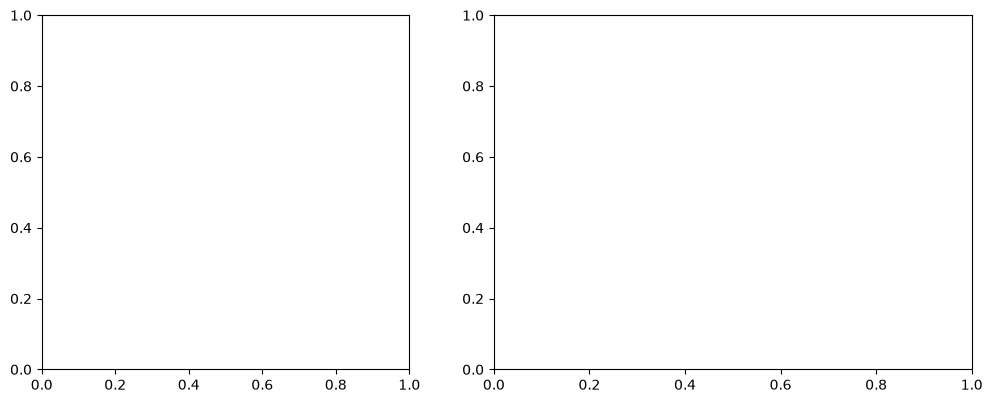

In [5]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.6),
                               gridspec_kw={"width_ratios": [1, 1.3]})

order = [t for t in site_stats["site_type"].cat.categories
         if (site_stats["site_type"] == t).any()]
axa.boxplot([site_stats.loc[site_stats["site_type"] == t, "median_increment"]
             for t in order], labels=order, widths=0.6)
axa.axhline(0, color="0.6", lw=0.8, ls="--")
axa.set_ylabel("median local increment (ug/m$^3$)")
axa.set_title("Local increment by site type")
axa.tick_params(axis="x", rotation=20)

axb.scatter(site_stats["km_from_centre"], site_stats["median_increment"],
            s=45, alpha=0.8, edgecolor="k", lw=0.4)
axb.axhline(0, color="0.6", lw=0.8, ls="--")
for c, r in site_stats.iterrows():
    if abs(r["median_increment"]) > site_stats["median_increment"].abs().quantile(0.85):
        axb.annotate(c, (r["km_from_centre"], r["median_increment"]),
                     xytext=(4, 4), textcoords="offset points", fontsize=8)
axb.set_xlabel("distance from City Square (km)")
axb.set_ylabel("median local increment (ug/m$^3$)")
axb.set_title("Increment against distance from the centre")

fig.tight_layout()
fig.savefig(OUT_FIGURES / "increment_by_site_type.png", dpi=200, bbox_inches="tight")
plt.show()

## 3  Comparing time series: what kind of source is it?

The average increment says how much a site adds; its shape through the day says what is adding it. Traffic emissions follow the working week, so a traffic-dominated site should show a weekday morning peak that weakens or disappears at the weekend. Domestic heating peaks in the evening and cares little about weekdays. Regional transport shows no diurnal structure at all once the baseline has been removed.

Profiles are computed on the increment rather than the measured concentration, because the measured value carries the boundary-layer cycle: concentrations rise overnight as the mixing depth collapses and fall after sunrise as it grows, which produces a diurnal cycle at every site whether or not anything is being emitted nearby. Removing the network baseline removes that shared meteorological cycle and leaves the part that is genuinely local.

In [ ]:
fig, axes = plt.subplots(1, len(order), figsize=(4.0 * len(order), 4),
                         sharey=True)
axes = np.atleast_1d(axes)

for ax, t in zip(axes, order):
    members = site_stats.index[site_stats["site_type"] == t]
    grp = incr[members].mean(axis=1)
    prof = diurnal_profile(grp, tz=LOCAL_TZ, by_daytype=True, stat="median")
    ax.plot(prof.index, prof["weekday"], marker="o", ms=3, label="weekday")
    ax.plot(prof.index, prof["weekend"], marker="o", ms=3, label="weekend")
    ax.axhline(0, color="0.6", lw=0.8, ls="--")
    ax.axvspan(7, 9, color="tab:grey", alpha=0.12)
    ax.axvspan(16, 18, color="tab:grey", alpha=0.12)
    ax.set_title(f"{t}  (n={len(members)})", fontsize=10)
    ax.set_xlabel("hour of day (local)")
    ax.set_xticks(range(0, 24, 6))

axes[0].set_ylabel("median local increment (ug/m$^3$)")
axes[0].legend(fontsize=8)
fig.suptitle("Diurnal local increment by site type — shaded bands mark commuting hours",
             y=1.02)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "diurnal_increment_by_sitetype.png", dpi=200,
            bbox_inches="tight")
plt.show()

In [ ]:
# Quantify the contrast rather than relying on the eye: the weekday-minus-weekend
# difference during commuting hours is a simple traffic index per sensor.
COMMUTE = [7, 8, 9, 16, 17, 18]

traffic_rows = {}
for c in site_stats.index:
    prof = diurnal_profile(incr[c].dropna(), tz=LOCAL_TZ, by_daytype=True,
                           stat="median")
    if prof["weekday"].notna().sum() < 20 or prof["weekend"].notna().sum() < 20:
        continue
    traffic_rows[c] = {
        "commute_weekday": prof.loc[COMMUTE, "weekday"].median(),
        "commute_weekend": prof.loc[COMMUTE, "weekend"].median(),
        "night_weekday":   prof.loc[[1, 2, 3, 4, 5], "weekday"].median(),
    }

traffic = pd.DataFrame(traffic_rows).T
traffic["traffic_index"] = (traffic["commute_weekday"]
                            - traffic["commute_weekend"]).round(2)
traffic = traffic.join(site_stats[["site_type", "km_from_centre"]]).round(2)
traffic.sort_values("traffic_index", ascending=False).to_csv(
    OUT_TABLES / "traffic_index_by_sensor.csv")

print("Weekday-minus-weekend increment during commuting hours (ug/m3):")
print(traffic.groupby("site_type", observed=True)["traffic_index"]
      .agg(["count", "median"]).round(2))
traffic.sort_values("traffic_index", ascending=False).head(10)

## 4  Instrument bias: offset and gain

The diagnostic rests on a simple physical argument. Restrict attention to hours when the network is spatially uniform, measured by a small inter-quartile range across sensors: under those conditions no local source is active anywhere, so every working sensor is looking at the same air. Any systematic departure from the network at those times is a property of the instrument, not of its surroundings.

Two departures are distinguished, because they have different causes and different remedies:

- an **additive offset** (intercept away from zero) is what a contaminated optical path or a drifting zero produces — the sensor adds a roughly constant amount whatever the air is doing;
- a **gain error** (slope away from one) is a calibration-slope problem — the sensor is proportionally wrong, so the error grows with concentration.

A median difference alone cannot tell them apart, because in clean air a constant offset also looks like a large ratio. Regressing each sensor against the network median across the concentration range separates them. The fit is made robust by binning the network median into deciles and fitting the bin medians, so no single unusual hour can drag the result.

In [ ]:
og = offset_gain(hm, tz=LOCAL_TZ, night_hours=None, n_bins=10,
                 q=BASELINE_Q, min_sensors=MIN_SENSORS_PER_HOUR,
                 spread_q=0.5, min_hours=200)

print(f"well-mixed hours used: {og.attrs['n_timestamps']:,} "
      f"(network IQR <= {og.attrs['max_spread_used']:.2f} ug/m3)")

bias = og.join(site_stats[["site_type", "km_from_centre"]])
bias.round(3).to_csv(OUT_TABLES / "instrument_bias.csv")

print("\nLargest additive offsets:")
print(bias.sort_values("offset_ugm3", ascending=False).head(6).round(3).to_string())
print("\nLargest gain departures:")
print(bias.reindex(bias["gain"].sub(1).abs().sort_values(ascending=False).index)
      .head(6).round(3).to_string())

In [ ]:
# The same test restricted to quiet nights, as a robustness check: if a sensor's
# offset is real it should not depend on whether daytime hours are included.
og_night = offset_gain(hm, tz=LOCAL_TZ, night_hours=NIGHT_HOURS, n_bins=6,
                       q=BASELINE_Q, min_sensors=MIN_SENSORS_PER_HOUR,
                       min_hours=100)

check = (og[["offset_ugm3", "gain"]]
         .join(og_night[["offset_ugm3", "gain"]], rsuffix="_night", how="inner")
         .round(3))
check["offset_diff"] = (check["offset_ugm3_night"] - check["offset_ugm3"]).round(3)
print(f"night-only hours: {og_night.attrs['n_timestamps']:,}")
print("\nAll-hours vs night-only estimates (large offset_diff = unstable):")
print(check.reindex(check["offset_ugm3"].abs().sort_values(ascending=False).index)
      .head(8).to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
sc = ax.scatter(bias["gain"], bias["offset_ugm3"],
                c=bias["km_from_centre"], cmap="viridis",
                s=55, edgecolor="k", lw=0.4)
ax.axhline(0, color="0.6", lw=0.9, ls="--")
ax.axvline(1, color="0.6", lw=0.9, ls="--")
plt.colorbar(sc, ax=ax, label="km from centre", shrink=0.85)

thr_o = bias["offset_ugm3"].abs().quantile(0.85)
thr_g = bias["gain"].sub(1).abs().quantile(0.85)
for c, r in bias.iterrows():
    if abs(r["offset_ugm3"]) > thr_o or abs(r["gain"] - 1) > thr_g:
        ax.annotate(c, (r["gain"], r["offset_ugm3"]), fontsize=8,
                    xytext=(5, 4), textcoords="offset points")

ax.set_xlabel("gain (slope against the network; 1 = unbiased)")
ax.set_ylabel("additive offset (ug/m$^3$; 0 = unbiased)")
ax.set_title("Instrument bias during well-mixed hours\n"
             "(top-right of the crosshair = reads high; sensors far from the "
             "crosshair need attention)")
fig.tight_layout()
fig.savefig(OUT_FIGURES / "instrument_offset_gain.png", dpi=200,
            bbox_inches="tight")
plt.show()

## 5  Cross-check: does the bias explain the CSI ranking?

The CSI and the bias estimate share no code and rest on different ideas — one counts how often pairs of sensors agree, the other regresses a sensor against the network under restricted conditions. If the sensors the CSI ranks lowest are also the ones carrying the largest bias, the two methods corroborate each other and the fault list is much harder to dismiss as an artefact of either method's assumptions.

This also supplies something the CSI could not: a bias in µg/m³, which is the quantity a site visit or a recalibration actually needs.

In [ ]:
rank = pd.read_csv(OUT_TABLES / "csi_sensor_ranking.csv", index_col=0)
rank.index = [short_code(i) for i in rank.index]

both = bias.join(rank[["mean_csi"]], how="inner").dropna(
    subset=["mean_csi", "offset_ugm3"])
both["abs_bias"] = (both["offset_ugm3"].abs()
                    + 10 * (both["gain"] - 1).abs()).round(3)

r_off  = both[["mean_csi", "offset_ugm3"]].corr(method="spearman").iloc[0, 1]
r_bias = both[["mean_csi", "abs_bias"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman(mean CSI, additive offset)  = {r_off:+.2f}  (n = {len(both)})")
print(f"Spearman(mean CSI, combined bias)    = {r_bias:+.2f}")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(both["offset_ugm3"], both["mean_csi"], s=55,
           edgecolor="k", lw=0.4, alpha=0.85)
ax.axvline(0, color="0.6", lw=0.9, ls="--")
for c, r in both.iterrows():
    if r["mean_csi"] < both["mean_csi"].quantile(0.20) or \
       abs(r["offset_ugm3"]) > both["offset_ugm3"].abs().quantile(0.85):
        ax.annotate(c, (r["offset_ugm3"], r["mean_csi"]), fontsize=8,
                    xytext=(5, 4), textcoords="offset points")
ax.set_xlabel("additive offset (ug/m$^3$)")
ax.set_ylabel("mean CSI (lifetime)")
ax.set_title("Two independent fault indicators\n"
             f"Spearman r = {r_off:+.2f}")
fig.tight_layout()
fig.savefig(OUT_FIGURES / "bias_vs_csi.png", dpi=200, bbox_inches="tight")
plt.show()

both.sort_values("mean_csi").head(8).round(3)

## 6  Events revisited as enhancement above baseline

The Bonfire Night analysis in notebook 06 compared the event evening with a control evening built from other November days. The baseline framework offers a cleaner statement of the same result: the enhancement is the increment above the concurrent regional background, so it needs no control days at all and is not vulnerable to the choice of which days count as normal. If the two approaches agree, the event result does not depend on that choice.

In [ ]:
inc_net = (net_median - base_spatial).dropna()
local_idx = inc_net.index.tz_convert(LOCAL_TZ)

rows = []
for yr in BONFIRE_YEARS:
    ev = ((local_idx >= f"{yr}-11-05 17:00") & (local_idx <= f"{yr}-11-06 01:00"))
    nov = ((local_idx >= f"{yr}-11-01") & (local_idx < f"{yr}-12-01")
           & np.isin(local_idx.hour, [17, 18, 19, 20, 21, 22, 23, 0, 1])
           & ~np.isin([f"{m:02d}-{d:02d}" for m, d in
                       zip(local_idx.month, local_idx.day)], EVENT_EXCLUDE))
    if ev.sum() == 0:
        continue
    rows.append({
        "year": yr,
        "event_increment": round(float(inc_net[ev].median()), 1),
        "november_increment": round(float(inc_net[nov].median()), 1),
        "event_hours": int(ev.sum()),
    })

bonfire_base = pd.DataFrame(rows).set_index("year")
bonfire_base["ratio"] = (bonfire_base["event_increment"]
                         / bonfire_base["november_increment"]).round(1)
bonfire_base.to_csv(OUT_TABLES / "bonfire_increment_above_baseline.csv")
print("Bonfire Night enhancement expressed as increment above the regional baseline:")
bonfire_base

## Summary

Fill in from the outputs above once run:

- the regional baseline accounts for roughly __ % of the median measured concentration, so most of what the network records is air it did not generate;
- local increments are largest at __ and near zero at __, and the increment falls with distance from the centre;
- the weekday-minus-weekend contrast during commuting hours is __ µg/m³ at roadside sites and __ elsewhere, which is the traffic contribution the raw series could not isolate;
- __ sensors carry an additive offset larger than __ µg/m³ and __ a gain error beyond __ %, and these are broadly the sensors the CSI ranks lowest (Spearman r = __), so two independent methods agree on the fault list;
- Bonfire Night remains a factor __ enhancement when expressed above the concurrent baseline rather than against control days, so that result does not depend on the choice of control period.